<a href="https://colab.research.google.com/github/rishik-dev/Decision_Tree_Regression/blob/main/KNN_AND_SVM_Machine_Learning_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('WineQT.csv')
print(df.head)

<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075  

In [3]:
X = df[['alcohol', 'volatile acidity']]

In [5]:
y = df['quality']

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [9]:
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

SVR()

In [13]:
 y_pred = model.predict(X_test)
 print(y_pred)

[5.13266271 4.84322687 5.62879611 5.01662418 6.1094571  6.34400743
 5.13266271 5.00332159 5.74968566 5.34297281 6.24687203 6.16851525
 5.65097074 6.21187716 6.00546469 5.13514369 5.35769797 5.67870786
 5.33715971 6.33708491 5.78500806 6.00879081 5.2079399  6.3390089
 5.58531596 5.19427002 6.42015997 5.72637607 4.97678512 5.54657704
 6.22687584 5.41331428 6.21187716 5.73552405 5.70004428 5.2500989
 5.48642349 5.82145826 6.43576387 5.33736205 6.10029547 5.33593445
 6.45943765 5.17681211 5.09990662 4.98441558 5.91209922 5.72141265
 4.89513367 5.87836997 6.36649256 5.13491407 5.55712478 5.75675964
 5.62914197 6.18253789 5.68554598 5.87009325 5.2673895  5.26055943
 5.30646455 6.03769307 5.74968566 6.05794787 6.17476966 5.47225034
 6.49742881 5.09254609 5.01955404 5.94863255 4.76406828 4.99455832
 5.65733783 6.20434475 5.07267443 5.10525349 5.88485567 5.46663052
 5.62914197 5.17374492 5.49350634 5.53465064 5.48255661 5.30774632
 5.44187028 6.00546469 5.85132924 5.64567978 5.87952508 5.105253

In [16]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.3847666102903235


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


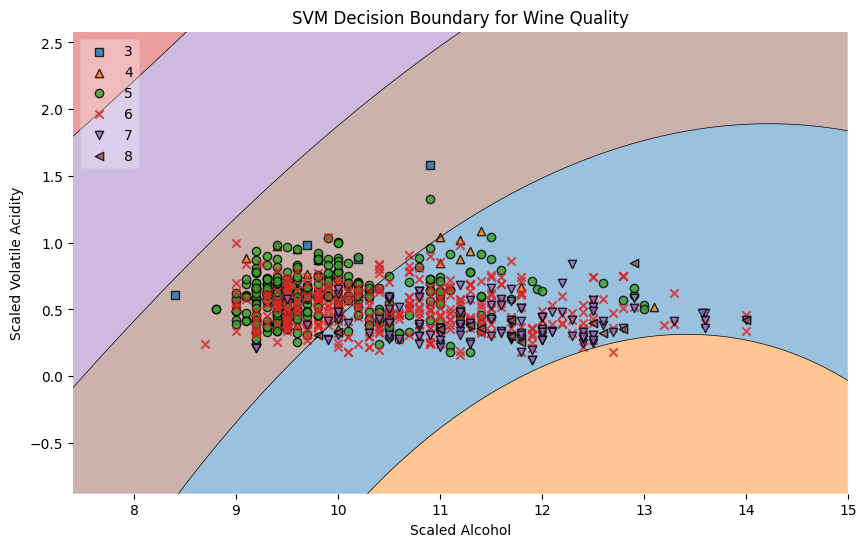

In [22]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

X_arr = X_train.values
y_arr = y_train.values.astype(int)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_arr, y_arr, clf=model, legend=2)

plt.xlabel('Scaled Alcohol')
plt.ylabel('Scaled Volatile Acidity')
plt.title('SVM Decision Boundary for Wine Quality')
plt.show()

In [23]:
# KNN MODEL

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [25]:
df = pd.read_csv('IRIS.csv')
print(df.head)

<bound method NDFrame.head of      sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]>


In [26]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

In [29]:
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))
])

In [30]:
model.fit(X_train, y_train)
print("KNN Classifier trained successfully!")

KNN Classifier trained successfully!


In [31]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"  Accuracy Score : {accuracy:.2%}")

  Accuracy Score : 66.81%


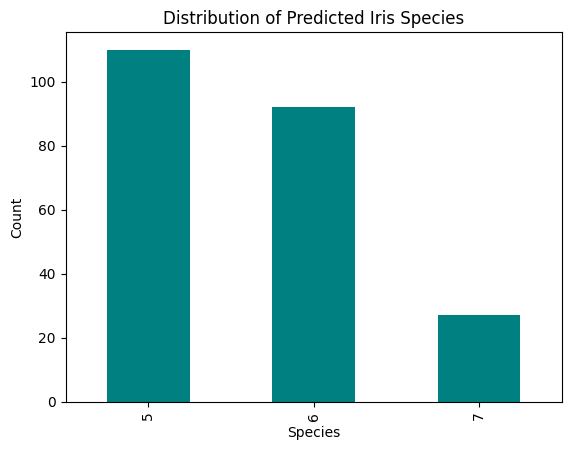

In [32]:
pd.Series(y_pred).value_counts().plot(kind='bar', color='teal')
plt.title('Distribution of Predicted Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()